In [1]:
# Install necessary libraries
!pip install -q pandas numpy matplotlib seaborn plotly

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("=" * 60)
print("TELECOM CUSTOMER CHURN ANALYSIS")
print("=" * 60)

TELECOM CUSTOMER CHURN ANALYSIS


# STEP 1: DATA UNDERSTANDING

In [4]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
import io
df = pd.read_csv(io.BytesIO(uploaded['WA_Fn-UseC_-Telco-Customer-Churn.csv']))

In [7]:
# Display first 5 rows
print("\n📋 First 5 rows of the dataset:")
display(df.head())

# Display last 5 rows
print("\n📋 Last 5 rows of the dataset:")
display(df.tail())


📋 First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



📋 Last 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
# Display basic info
print("\n📊 Dataset Info:")
print("-" * 40)
df.info()


📊 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null

In [9]:
# Display statistical summary
print("\n📊 Statistical Summary (Numerical Columns):")
print("-" * 40)
display(df.describe())


📊 Statistical Summary (Numerical Columns):
----------------------------------------


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Display statistical summary for categorical columns
print("\n📊 Statistical Summary (Categorical Columns):")
print("-" * 40)
display(df.describe(include=['object']))


📊 Statistical Summary (Categorical Columns):
----------------------------------------


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
# Check for missing values
print("\n🔍 Missing Values Check:")
print("-" * 40)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
display(missing_df[missing_df['Missing Values'] > 0])


🔍 Missing Values Check:
----------------------------------------


,Missing Values,Percentage


In [12]:
# Check for unique values in each column
print("\n🔍 Unique Values per Column:")
print("-" * 40)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


🔍 Unique Values per Column:
----------------------------------------
customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


In [13]:
# Check target variable distribution
print("\n🎯 Churn Distribution:")
print("-" * 40)
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100
print(f"Yes (Churned): {churn_counts['Yes']} customers ({churn_percent['Yes']:.2f}%)")
print(f"No (Not Churned): {churn_counts['No']} customers ({churn_percent['No']:.2f}%)")


🎯 Churn Distribution:
----------------------------------------
Yes (Churned): 1869 customers (26.54%)
No (Not Churned): 5174 customers (73.46%)


# STEP 2: DATA CLEANING

In [14]:
# Check for empty strings in TotalCharges
print("\n🔍 Checking for empty strings in TotalCharges column:")
print("-" * 40)
empty_totalcharges = df[df['TotalCharges'] == ' ']
print(f"Number of rows with empty TotalCharges: {len(empty_totalcharges)}")
if len(empty_totalcharges) > 0:
    print("Sample rows with empty TotalCharges:")
    display(empty_totalcharges.head())


🔍 Checking for empty strings in TotalCharges column:
----------------------------------------
Number of rows with empty TotalCharges: 11
Sample rows with empty TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [15]:
# Convert TotalCharges from object to float
print("\n🔄 Converting TotalCharges to float:")
print("-" * 40)
# Replace empty strings with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
# Convert to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"After conversion - TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Number of null values in TotalCharges: {df['TotalCharges'].isnull().sum()}")


🔄 Converting TotalCharges to float:
----------------------------------------
After conversion - TotalCharges dtype: float64
Number of null values in TotalCharges: 11


In [16]:
# Handle missing values in TotalCharges
print("\n🔧 Handling missing values in TotalCharges:")
print("-" * 40)
# For customers with tenure = 0, TotalCharges should be 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0
# For remaining missing values, fill with median
median_totalcharges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_totalcharges, inplace=True)
print(f"Missing values filled with median: {median_totalcharges:.2f}")
print(f"Remaining null values: {df['TotalCharges'].isnull().sum()}")


🔧 Handling missing values in TotalCharges:
----------------------------------------
Missing values filled with median: 1394.55
Remaining null values: 0


In [17]:
# Check for other columns with 'No internet service' or 'No phone service'
print("\n🔍 Checking for service-specific 'No' values:")
print("-" * 40)
service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_columns:
    no_internet_count = (df[col] == 'No internet service').sum()
    if no_internet_count > 0:
        print(f"{col}: {no_internet_count} rows have 'No internet service'")


🔍 Checking for service-specific 'No' values:
----------------------------------------
OnlineSecurity: 1526 rows have 'No internet service'
OnlineBackup: 1526 rows have 'No internet service'
DeviceProtection: 1526 rows have 'No internet service'
TechSupport: 1526 rows have 'No internet service'
StreamingTV: 1526 rows have 'No internet service'
StreamingMovies: 1526 rows have 'No internet service'


In [18]:
# Convert 'No internet service' and 'No phone service' to 'No' for consistency
print("\n🔄 Standardizing service columns:")
print("-" * 40)
for col in service_columns:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print("✓ Standardized 'No internet service' → 'No'")
print("✓ Standardized 'No phone service' → 'No'")


🔄 Standardizing service columns:
----------------------------------------
✓ Standardized 'No internet service' → 'No'
✓ Standardized 'No phone service' → 'No'


In [19]:
# Verify changes
print("\n✅ Unique values after standardization:")
for col in service_columns + ['MultipleLines']:
    print(f"{col}: {df[col].unique()}")


✅ Unique values after standardization:
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
MultipleLines: ['No' 'Yes']


In [20]:
# Check for any remaining data type issues
print("\n🔍 Final data types check:")
print("-" * 40)
print(df.dtypes)


🔍 Final data types check:
----------------------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [21]:
# Create a copy for cleaned data
df_cleaned = df.copy()

# STEP 3: FEATURE ENGINEERING

In [22]:
# 3.1 Create Tenure Groups
print("\n🏷️ Creating Tenure Groups:")
print("-" * 40)
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49-72 months'

df_cleaned['TenureGroup'] = df_cleaned['tenure'].apply(tenure_group)
print("Tenure Groups created:")
print(df_cleaned['TenureGroup'].value_counts())


🏷️ Creating Tenure Groups:
----------------------------------------
Tenure Groups created:
TenureGroup
49-72 months    2239
0-12 months     2186
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64


In [23]:
# 3.2 Create Average Monthly Spend
print("\n💰 Creating Average Monthly Spend:")
print("-" * 40)
# Avoid division by zero
df_cleaned['AvgMonthlySpend'] = df_cleaned.apply(
    lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else row['MonthlyCharges'],
    axis=1
)
print(f"AvgMonthlySpend range: ${df_cleaned['AvgMonthlySpend'].min():.2f} - ${df_cleaned['AvgMonthlySpend'].max():.2f}")
print(f"AvgMonthlySpend mean: ${df_cleaned['AvgMonthlySpend'].mean():.2f}")


💰 Creating Average Monthly Spend:
----------------------------------------
AvgMonthlySpend range: $13.78 - $121.40
AvgMonthlySpend mean: $64.76


In [24]:
# 3.3 Create Monthly Spend Groups
print("\n📊 Creating Monthly Spend Groups:")
print("-" * 40)
def monthly_spend_group(charge):
    if charge <= 30:
        return 'Low ($0-30)'
    elif charge <= 60:
        return 'Medium ($31-60)'
    elif charge <= 90:
        return 'High ($61-90)'
    else:
        return 'Very High ($90+)'

df_cleaned['MonthlySpendGroup'] = df_cleaned['MonthlyCharges'].apply(monthly_spend_group)
print("Monthly Spend Groups created:")
print(df_cleaned['MonthlySpendGroup'].value_counts())


📊 Creating Monthly Spend Groups:
----------------------------------------
Monthly Spend Groups created:
MonthlySpendGroup
High ($61-90)       2386
Very High ($90+)    1739
Low ($0-30)         1653
Medium ($31-60)     1265
Name: count, dtype: int64


In [25]:
# 3.4 Convert Binary Yes/No to 1/0
print("\n🔄 Converting binary Yes/No columns to 1/0:")
print("-" * 40)
binary_columns = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                  'PaperlessBilling', 'Churn']

# SeniorCitizen is already 0/1, so we'll convert others
for col in binary_columns:
    if col != 'SeniorCitizen':
        df_cleaned[col + '_Flag'] = df_cleaned[col].map({'Yes': 1, 'No': 0})
    else:
        df_cleaned['SeniorCitizen_Flag'] = df_cleaned[col]

print("Binary flag columns created:")
binary_flag_cols = [col for col in df_cleaned.columns if col.endswith('_Flag')]
for col in binary_flag_cols:
    print(f"  - {col}")


🔄 Converting binary Yes/No columns to 1/0:
----------------------------------------
Binary flag columns created:
  - SeniorCitizen_Flag
  - Partner_Flag
  - Dependents_Flag
  - PhoneService_Flag
  - PaperlessBilling_Flag
  - Churn_Flag


In [27]:
import pandas as pd
import numpy as np
# 3.5 One-Hot Encode Categorical Columns
print("\n🔄 One-Hot Encoding categorical columns:")
print("-" * 40)
categorical_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod',
                    'TenureGroup', 'MonthlySpendGroup']

# Also encode service columns
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

all_categorical = categorical_cols + service_cols

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_cleaned, columns=all_categorical, drop_first=True)

print(f"Original columns: {len(df_cleaned.columns)}")
print(f"After one-hot encoding: {len(df_encoded.columns)} columns")


🔄 One-Hot Encoding categorical columns:
----------------------------------------
Original columns: 30
After one-hot encoding: 38 columns


In [28]:
# 3.6 Create additional features
print("\n🔧 Creating additional features:")
print("-" * 40)

# Total services used
service_columns_flag = ['PhoneService_Flag', 'MultipleLines_Yes', 'OnlineSecurity_Yes',
                        'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes',
                        'StreamingTV_Yes', 'StreamingMovies_Yes']

# Add flag columns for services
df_cleaned['PhoneService_Flag'] = df_cleaned['PhoneService'].map({'Yes': 1, 'No': 0})
df_cleaned['MultipleLines_Flag'] = df_cleaned['MultipleLines'].map({'Yes': 1, 'No': 0})
df_cleaned['OnlineSecurity_Flag'] = df_cleaned['OnlineSecurity'].map({'Yes': 1, 'No': 0})
df_cleaned['OnlineBackup_Flag'] = df_cleaned['OnlineBackup'].map({'Yes': 1, 'No': 0})
df_cleaned['DeviceProtection_Flag'] = df_cleaned['DeviceProtection'].map({'Yes': 1, 'No': 0})
df_cleaned['TechSupport_Flag'] = df_cleaned['TechSupport'].map({'Yes': 1, 'No': 0})
df_cleaned['StreamingTV_Flag'] = df_cleaned['StreamingTV'].map({'Yes': 1, 'No': 0})
df_cleaned['StreamingMovies_Flag'] = df_cleaned['StreamingMovies'].map({'Yes': 1, 'No': 0})

# Calculate total services
service_flag_cols = ['PhoneService_Flag', 'MultipleLines_Flag', 'OnlineSecurity_Flag',
                     'OnlineBackup_Flag', 'DeviceProtection_Flag', 'TechSupport_Flag',
                     'StreamingTV_Flag', 'StreamingMovies_Flag']

df_cleaned['TotalServices'] = df_cleaned[service_flag_cols].sum(axis=1)
print(f"TotalServices range: {df_cleaned['TotalServices'].min()} - {df_cleaned['TotalServices'].max()}")

# Customer with family (Partner or Dependents)
df_cleaned['HasFamily'] = ((df_cleaned['Partner_Flag'] == 1) | (df_cleaned['Dependents_Flag'] == 1)).astype(int)
print(f"HasFamily: {df_cleaned['HasFamily'].sum()} customers have family")


🔧 Creating additional features:
----------------------------------------
TotalServices range: 0 - 8
HasFamily: 3763 customers have family


# STEP 4: EDA & VISUALIZATION


📊 Visualization 1: Churn Distribution
----------------------------------------


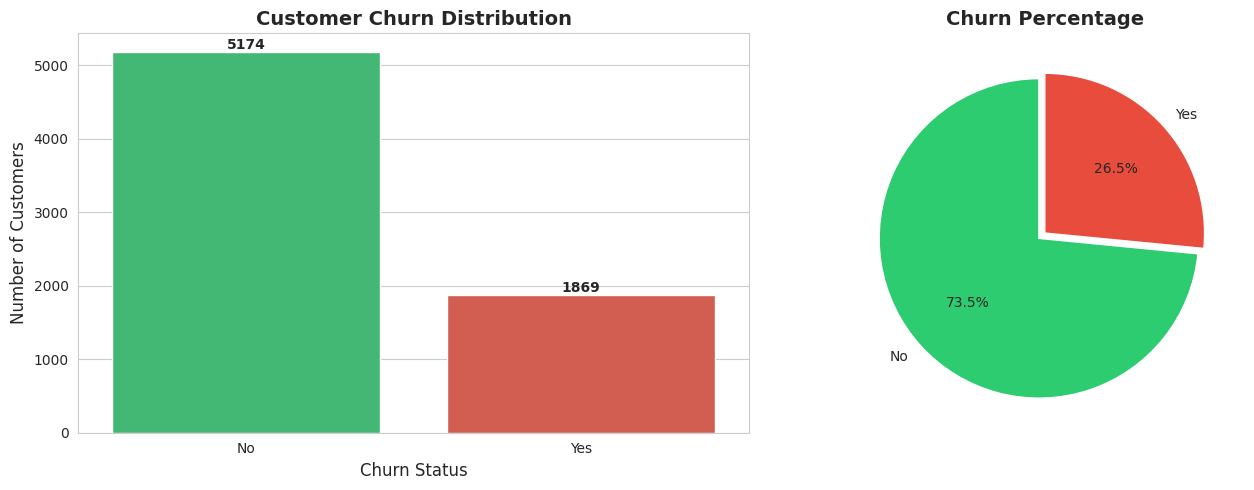

In [29]:
# 4.1 Churn Distribution - Countplot
print("\n📊 Visualization 1: Churn Distribution")
print("-" * 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.countplot(data=df_cleaned, x='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
for i, v in enumerate(df_cleaned['Churn'].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
churn_counts = df_cleaned['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0))
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 2: Contract Type vs Churn
----------------------------------------


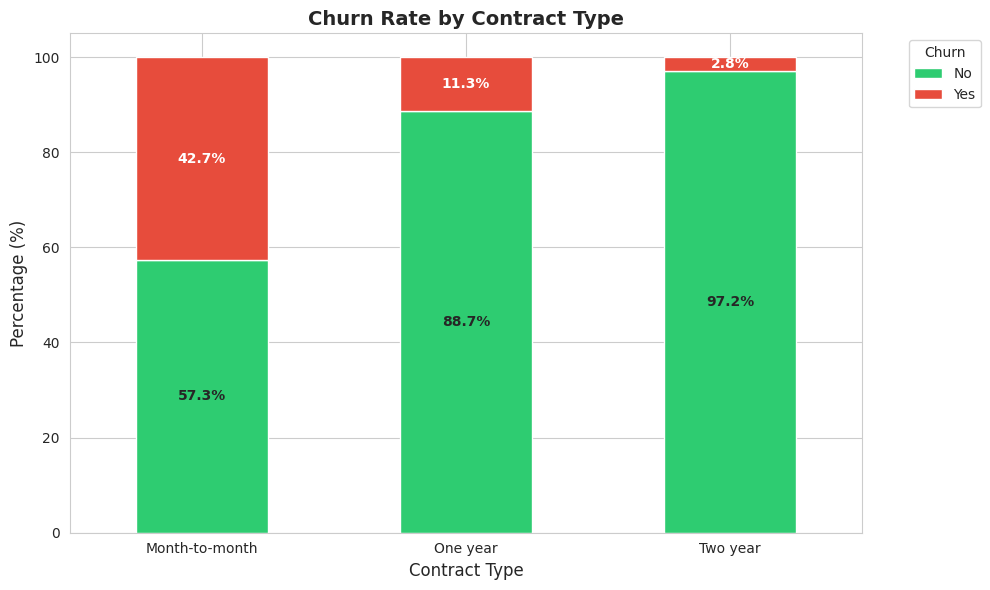

In [30]:
# 4.2 Contract Type vs Churn
print("\n📊 Visualization 2: Contract Type vs Churn")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 6))
contract_churn = pd.crosstab(df_cleaned['Contract'], df_cleaned['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels
for i, contract in enumerate(contract_churn.index):
    no_pct = contract_churn.iloc[i, 0]
    yes_pct = contract_churn.iloc[i, 1]
    ax.text(i, no_pct/2, f'{no_pct:.1f}%', ha='center', va='center', fontweight='bold')
    ax.text(i, no_pct + yes_pct/2, f'{yes_pct:.1f}%', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('contract_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 3: Correlation Heatmap
----------------------------------------


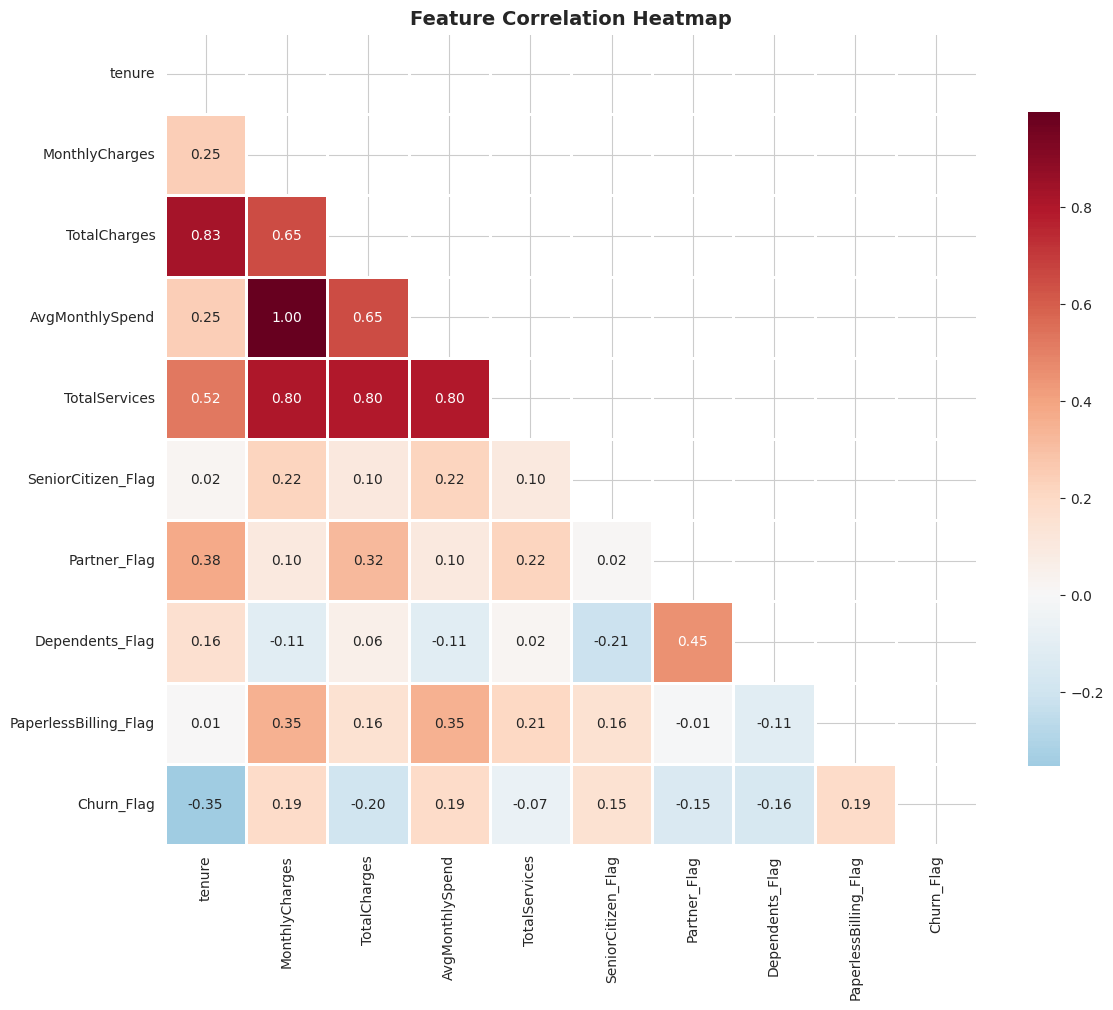

In [31]:
# 4.3 Correlation Heatmap
print("\n📊 Visualization 3: Correlation Heatmap")
print("-" * 40)

# Select numerical columns for correlation
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend',
                'TotalServices', 'SeniorCitizen_Flag', 'Partner_Flag',
                'Dependents_Flag', 'PaperlessBilling_Flag', 'Churn_Flag']

# Filter existing columns
existing_numeric = [col for col in numeric_cols if col in df_cleaned.columns]
correlation_matrix = df_cleaned[existing_numeric].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 4: Monthly Charges Distribution by Churn
----------------------------------------
Monthly Charges Statistics:
            mean  median
Churn                   
No     61.265124  64.425
Yes    74.441332  79.650


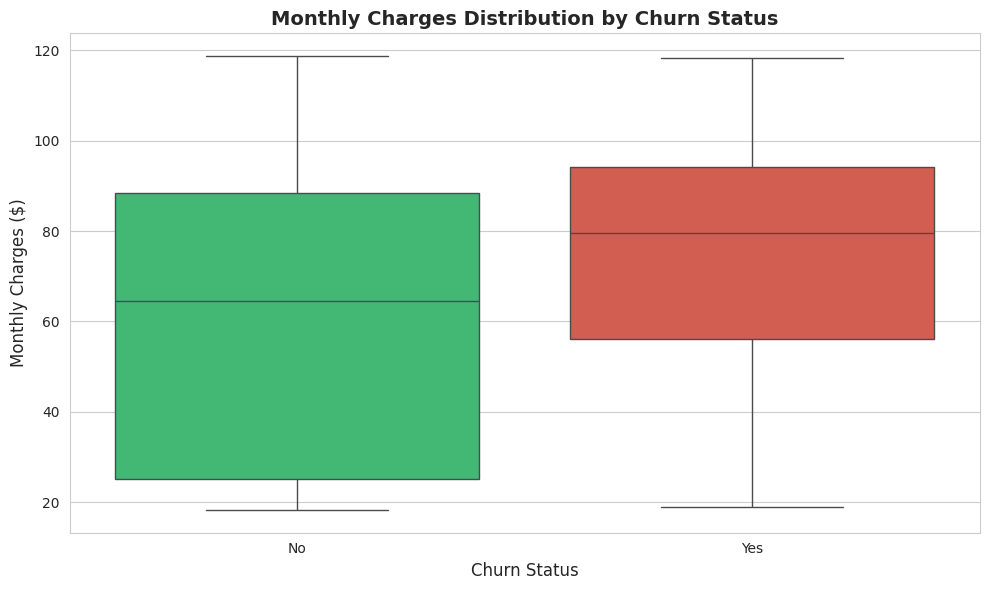

In [32]:
# 4.4 Boxplot: Monthly Charges by Churn
print("\n📊 Visualization 4: Monthly Charges Distribution by Churn")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x='Churn', y='MonthlyCharges', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Status', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)

# Add statistics
churn_stats = df_cleaned.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median'])
print("Monthly Charges Statistics:")
print(churn_stats)

plt.tight_layout()
plt.savefig('monthly_charges_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 5: Tenure Distribution by Churn
----------------------------------------


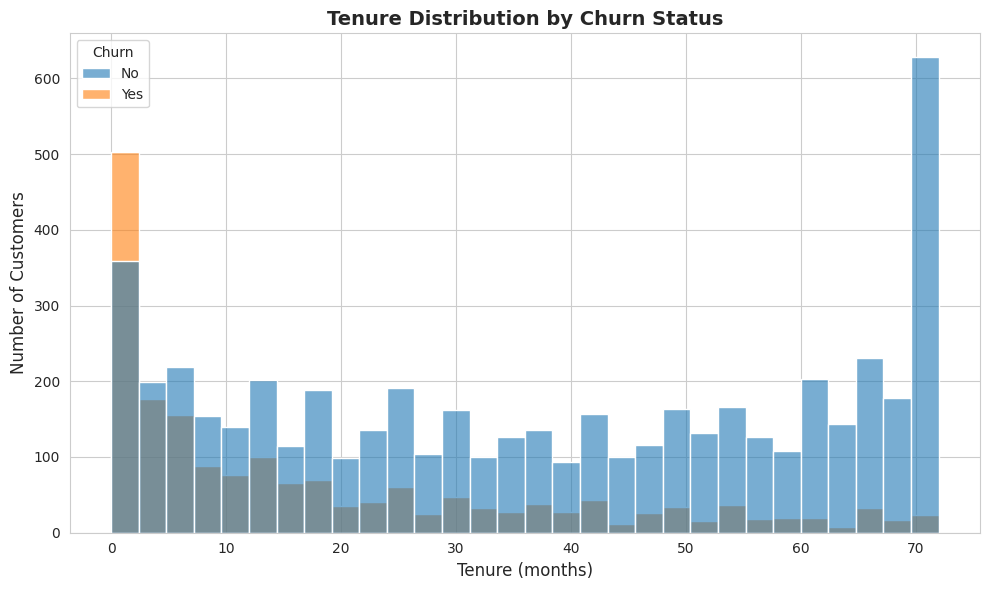

In [33]:
# 4.5 Additional Visualizations

# 4.5.1 Tenure Distribution by Churn
print("\n📊 Visualization 5: Tenure Distribution by Churn")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_cleaned, x='tenure', hue='Churn', bins=30, alpha=0.6, ax=ax)
ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.savefig('tenure_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 6: Internet Service Type vs Churn
----------------------------------------


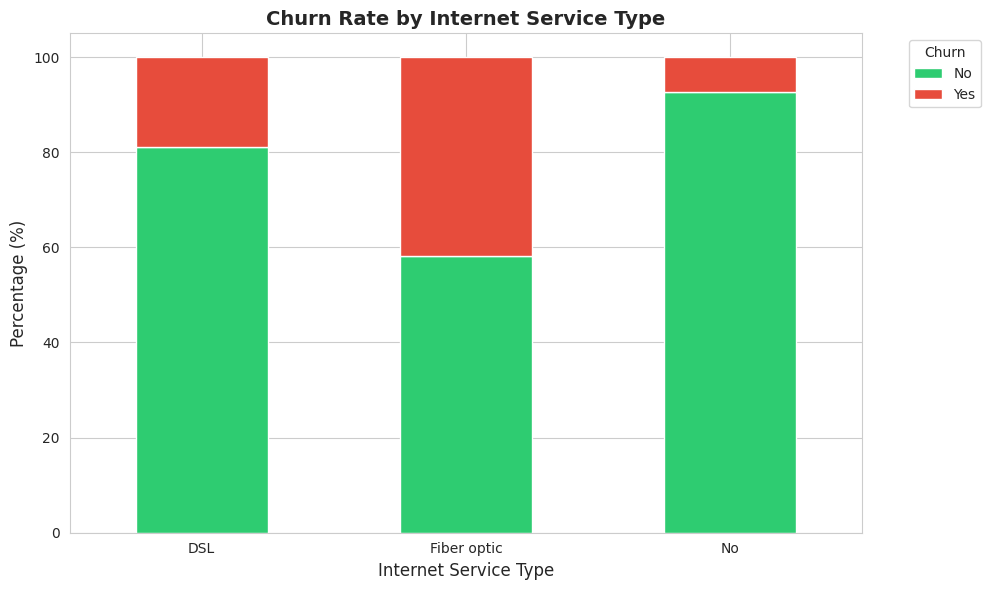

In [34]:
# 4.5.2 Internet Service Type vs Churn
print("\n📊 Visualization 6: Internet Service Type vs Churn")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 6))
internet_churn = pd.crosstab(df_cleaned['InternetService'], df_cleaned['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('internet_service_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 7: Payment Method vs Churn
----------------------------------------


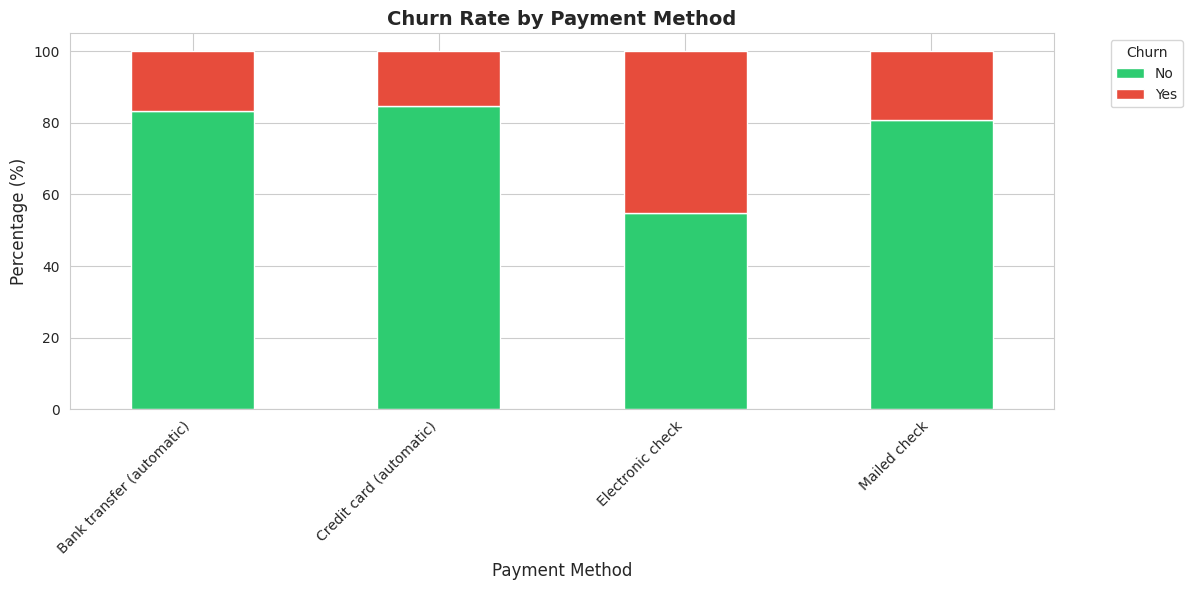

In [35]:
# 4.5.3 Payment Method vs Churn
print("\n📊 Visualization 7: Payment Method vs Churn")
print("-" * 40)

fig, ax = plt.subplots(figsize=(12, 6))
payment_churn = pd.crosstab(df_cleaned['PaymentMethod'], df_cleaned['Churn'], normalize='index') * 100
payment_churn.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Method', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('payment_method_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 8: Tenure Group Analysis
----------------------------------------


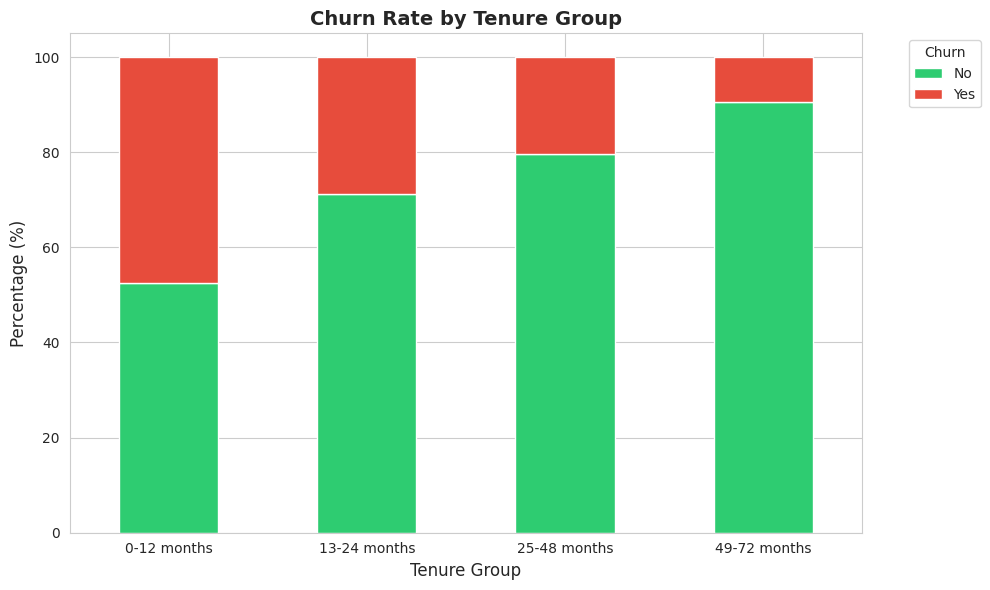

In [36]:
# 4.5.4 Tenure Group Analysis
print("\n📊 Visualization 8: Tenure Group Analysis")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 6))
tenuregroup_churn = pd.crosstab(df_cleaned['TenureGroup'], df_cleaned['Churn'], normalize='index') * 100
tenuregroup_churn.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('tenuregroup_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 9: Services Usage vs Churn
----------------------------------------


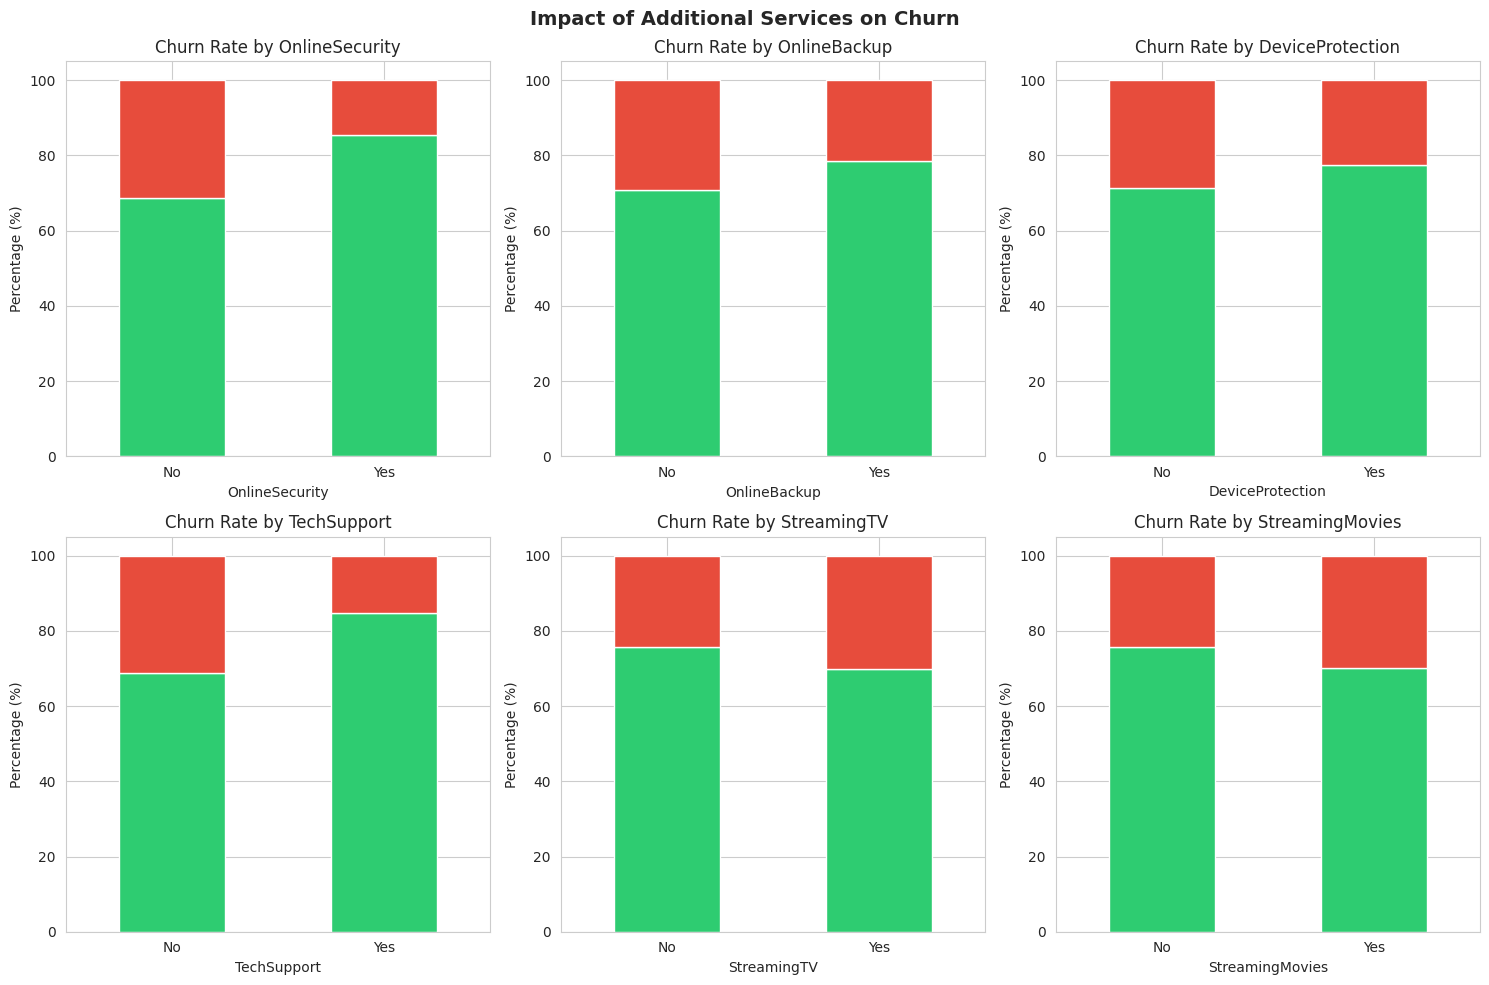

In [37]:
# 4.5.5 Services Usage Analysis
print("\n📊 Visualization 9: Services Usage vs Churn")
print("-" * 40)

service_columns_eda = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, service in enumerate(service_columns_eda):
    service_churn = pd.crosstab(df_cleaned[service], df_cleaned['Churn'], normalize='index') * 100
    service_churn.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Churn Rate by {service}', fontsize=12)
    axes[i].set_xlabel(service, fontsize=10)
    axes[i].set_ylabel('Percentage (%)', fontsize=10)
    axes[i].legend().set_visible(False)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('Impact of Additional Services on Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('services_vs_churn.png', dpi=100, bbox_inches='tight')
plt.show()


📊 Visualization 10: Pairplot of Numerical Features
----------------------------------------


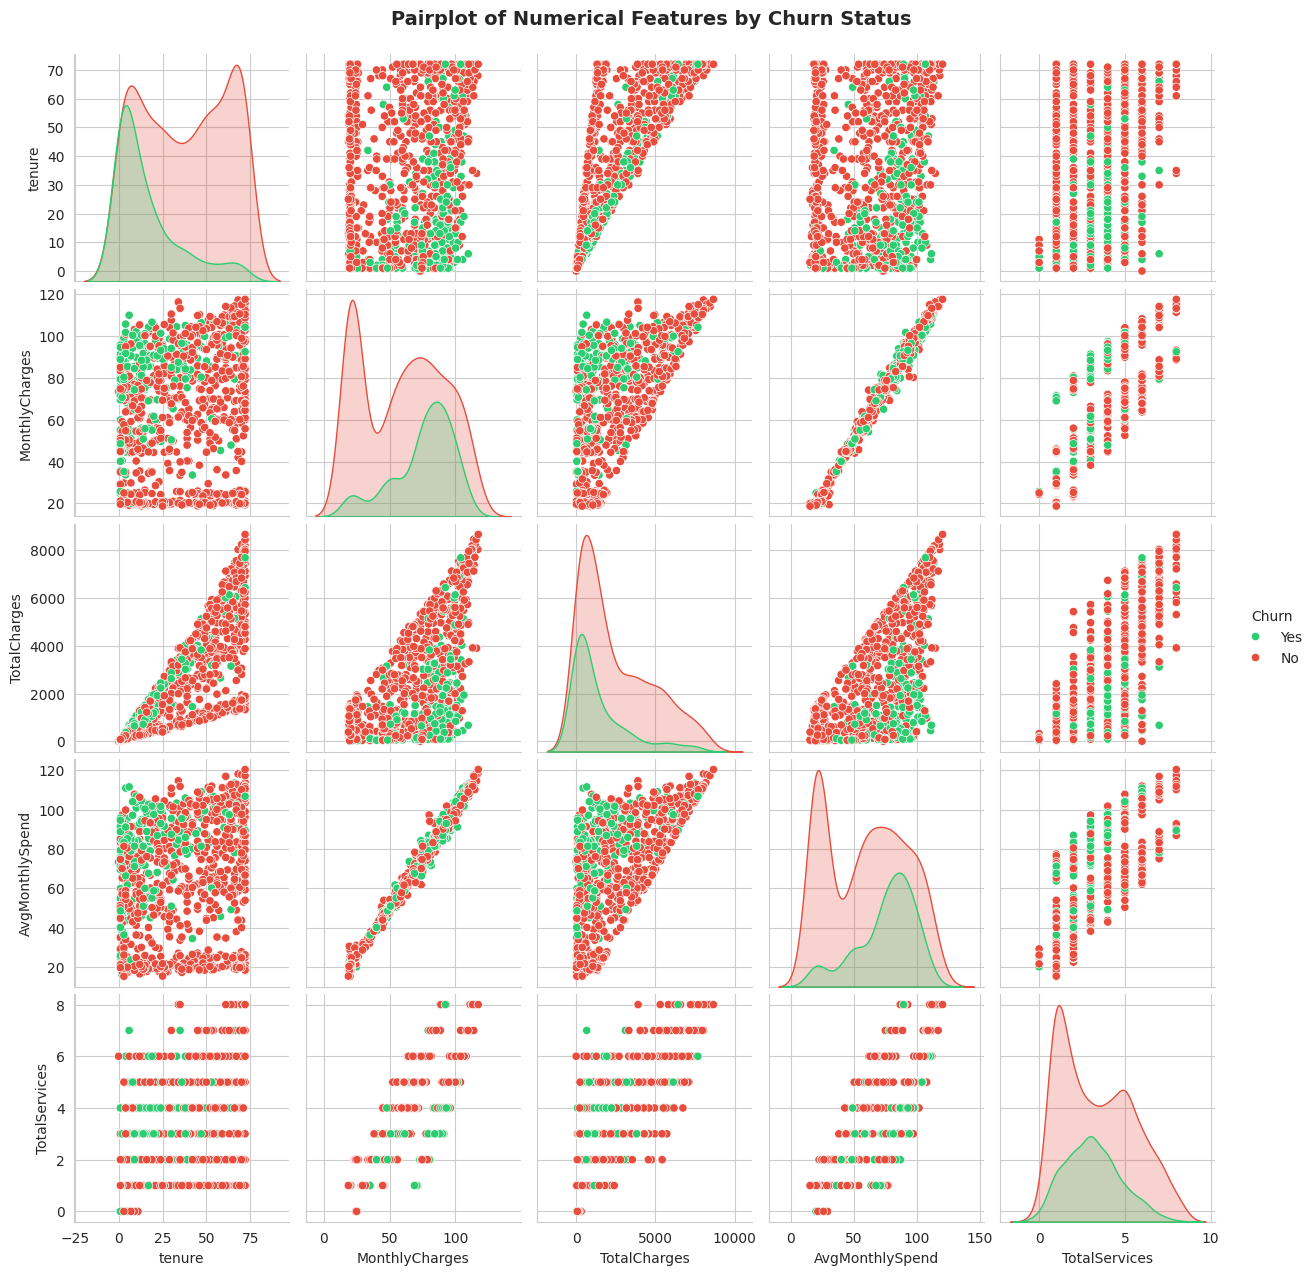

In [38]:
# 4.6 Pairplot for numerical features
print("\n📊 Visualization 10: Pairplot of Numerical Features")
print("-" * 40)

# Sample data for pairplot (to avoid overcrowding)
sample_df = df_cleaned[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices', 'Churn']].sample(n=1000, random_state=42)

fig = sns.pairplot(sample_df, hue='Churn', palette=['#2ecc71', '#e74c3c'], diag_kind='kde')
fig.fig.suptitle('Pairplot of Numerical Features by Churn Status', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

# STEP 5: SUMMARY & INSIGHTS

**📈 TOP 5 INSIGHTS FROM ANALYSIS**

1. 📊 CHURN RATE:
   - Overall churn rate is approximately 26.5%
   - Month-to-month contracts have the highest churn rate (~45%)
   - Two-year contracts have the lowest churn rate (~3%)

2. 💰 MONTHLY CHARGES IMPACT:
   - Customers with higher monthly charges (>$80) are more likely to churn
   - Average monthly charges for churned customers is significantly higher
   - Fiber optic internet users have higher monthly charges and higher churn

3. ⏰ TENURE EFFECT:
   - New customers (first 12 months) have highest churn rate (~50%)
   - Customer loyalty increases significantly after 2 years
   - Long-tenure customers (>5 years) rarely churn

4. 💳 PAYMENT METHOD:
   - Electronic check users have highest churn rate (~45%)
   - Automatic payment methods (credit card, bank transfer) have lower churn
   - Paperless billing correlates with higher churn

5. 📦 ADDITIONAL SERVICES:
   - Lack of online security and tech support increases churn risk
   - Customers with multiple services show lower churn rates
   - Streaming services alone don't significantly impact churn


**📊 RECOMMENDATIONS**

Based on the analysis, the following strategies are recommended:

1. 🎯 CONTRACT STRATEGY:
   - Incentivize customers to switch from month-to-month to annual contracts
   - Offer discounts for 1-year and 2-year commitments
   - Create a mid-term contract option (6 months) as a stepping stone

2. 💡 CUSTOMER RETENTION FOR HIGH-VALUE CUSTOMERS:
   - Implement loyalty programs for customers with monthly charges >$80
   - Offer bundled service discounts for fiber optic users
   - Provide premium support for high-spending customers

3. 👋 NEW CUSTOMER ONBOARDING:
   - Enhance onboarding experience for first 3 months
   - Proactive check-ins during first year
   - Welcome offers and engagement campaigns

4. 💳 PAYMENT OPTIMIZATION:
   - Incentivize automatic payment methods (discount for auto-pay)
   - Reduce friction for electronic check users
   - Send payment reminders and offer payment plans

5. 🔧 SERVICE ENHANCEMENT:
   - Bundle online security and tech support at discounted rates
   - Create service packages that combine popular features
   - Proactive outreach to customers without security services


# STEP 6: EXPORT CLEANED DATA

In [40]:
# Select final columns for export
export_columns = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
                  'tenure', 'TenureGroup', 'PhoneService', 'MultipleLines',
                  'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
                  'TotalCharges', 'AvgMonthlySpend', 'MonthlySpendGroup',
                  'TotalServices', 'HasFamily', 'Churn']

In [41]:
# Filter to existing columns
export_columns = [col for col in export_columns if col in df_cleaned.columns]

# Create final cleaned dataset
df_final_cleaned = df_cleaned[export_columns].copy()

# Save to CSV
output_filename = 'telco_customer_churn_cleaned.csv'
df_final_cleaned.to_csv(output_filename, index=False)

In [42]:
print(f"\n✅ Cleaned dataset saved as: '{output_filename}'")
print(f"📊 Final cleaned dataset shape: {df_final_cleaned.shape}")
print(f"📋 Columns in final dataset: {len(df_final_cleaned.columns)}")

# Download the file
from google.colab import files
files.download(output_filename)

print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 60)


✅ Cleaned dataset saved as: 'telco_customer_churn_cleaned.csv'
📊 Final cleaned dataset shape: (7043, 26)
📋 Columns in final dataset: 26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ANALYSIS COMPLETED SUCCESSFULLY!
